## 0. Settings

In [ ]:
pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn import svm
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import time



## 1. Data loading

In [ ]:
#If you use a drive
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Article sound/stats1.csv', sep=";")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#If you use work on github
#df = pd.read_csv('https://raw.githubusercontent.com/foguedjombou/stone-impact-sound-analysis/stats.csv')

## 2. Preprocessings

#### Data **shaping**

In [ ]:
df.iloc[28, 2:4] = 0
df

,sample_name,form,frost_resistance,Q_vibration_initial,rms_1,rms_2,rms_3,rms_4,rms_5,rms_6,...,centroid_mean,centroid_std,centroid_min,centroid_max,d_centroid,c_mean,c_std,c_min,c_max,d_c
0,S01,pl,1,135.135135,0.122204,0.129421,0.111234,0.128124,0.130879,0.114371,...,6012.621609,589.024741,4881.061628,6893.026751,2011.965123,60.477033,3.449210,55.140871,66.255863,11.114992
1,S02,pl,1,119.047619,0.118736,0.145612,0.109484,0.137154,0.138425,0.132420,...,6911.786747,1151.963200,5358.211364,8567.668763,3209.457399,53.673212,2.587895,48.540497,56.854063,8.313566
2,S03,pl,1,81.967213,0.105056,0.118863,0.093317,0.106551,0.100342,0.093870,...,5459.906511,652.005642,4558.928434,6197.090933,1638.162499,54.272403,6.250442,44.583643,62.897749,18.314106
3,S04,pt,1,125.000000,0.103743,0.107076,0.106194,NaN,NaN,NaN,...,8189.893378,1005.291861,7279.460418,9268.764887,1989.304469,101.376921,4.126432,96.625126,104.057411,7.432285
4,S05,pt,1,131.578947,0.106428,0.103779,0.109662,NaN,NaN,NaN,...,7017.449919,698.488585,6278.363827,7666.635800,1388.271973,92.852775,5.320721,86.709230,95.976631,9.267401
5,S06,pt,1,116.279070,0.102041,0.102716,0.102248,NaN,NaN,NaN,...,7115.259415,217.196343,6869.146299,7280.095180,410.948881,105.931849,3.683444,103.432419,110.161899,6.729480
6,S07,pt,1,111.111111,0.117247,0.121782,NaN,NaN,NaN,NaN,...,7694.798151,634.360661,7246.237426,8143.358876,897.121450,68.112623,0.766591,67.570562,68.654684,1.084123
7,S08,pt,1,79.365079,0.150835,0.161233,0.144541,NaN,NaN,NaN,...,5347.441113,388.359444,5078.519540,5792.681481,714.161941,43.131979,0.602065,42.526667,43.730744,1.204076
8,S09,pt,1,131.578947,0.142040,0.136088,0.133269,NaN,NaN,NaN,...,5691.594200,120.390900,5596.319438,5826.901464,230.582027,55.077694,0.974967,53.960332,55.755492,1.795160
9,S10,pt,1,60.240964,0.139613,0.143177,0.131833,NaN,NaN,NaN,...,5955.162487,122.788945,5823.560949,6066.656816,243.095867,52.387126,3.142826,50.166816,55.983247,5.816431


In [ ]:
#table with only statistical data
X = df.drop(['sample_name',
'form',
 'rms_1',
 'rms_2',
 'rms_3',
 'rms_4',
 'rms_5',
 'rms_6',
 'rms_7',
 'rms_8',
 'rms_9',
 'flatness_1',
 'flatness_2',
 'flatness_3',
 'flatness_4',
 'flatness_5',
 'flatness_6',
 'flatness_7',
 'flatness_8',
 'flatness_9',
 'rolloff_1',
 'rolloff_2',
 'rolloff_3',
 'rolloff_4',
 'rolloff_5',
 'rolloff_6',
 'rolloff_7',
 'rolloff_8',
 'rolloff_9',
 'contrast_1',
 'contrast_2',
 'contrast_3',
 'contrast_4',
 'contrast_5',
 'contrast_6',
 'contrast_7',
 'contrast_8',
 'contrast_9',
 'fpeak_1',
 'fpeak_2',
 'fpeak_3',
 'fpeak_4',
 'fpeak_5',
 'fpeak_6',
 'fpeak_7',
 'fpeak_8',
 'fpeak_9',
 'c_1',
 'c_2',
 'c_3',
 'c_4',
 'c_5',
 'c_6',
 'c_7',
 'c_8',
 'c_9',
 'centroid_1',
 'centroid_2',
 'centroid_3',
 'centroid_4',
 'centroid_5',
 'centroid_6',
 'centroid_7',
 'centroid_8',
 'centroid_9',
 'frost_resistance',
 'Q_vibration_initial'
                 ],axis=1)


In [ ]:
df_pl = df[df["form"] == "pl"]
df_pt = df[df["form"] == "pt"]

In [ ]:
#table with only statistical data
X_pl = df_pl.drop(['sample_name',
'form',
 'rms_1',
 'rms_2',
 'rms_3',
 'rms_4',
 'rms_5',
 'rms_6',
 'rms_7',
 'rms_8',
 'rms_9',
 'flatness_1',
 'flatness_2',
 'flatness_3',
 'flatness_4',
 'flatness_5',
 'flatness_6',
 'flatness_7',
 'flatness_8',
 'flatness_9',
 'rolloff_1',
 'rolloff_2',
 'rolloff_3',
 'rolloff_4',
 'rolloff_5',
 'rolloff_6',
 'rolloff_7',
 'rolloff_8',
 'rolloff_9',
 'contrast_1',
 'contrast_2',
 'contrast_3',
 'contrast_4',
 'contrast_5',
 'contrast_6',
 'contrast_7',
 'contrast_8',
 'contrast_9',
 'fpeak_1',
 'fpeak_2',
 'fpeak_3',
 'fpeak_4',
 'fpeak_5',
 'fpeak_6',
 'fpeak_7',
 'fpeak_8',
 'fpeak_9',
 'c_1',
 'c_2',
 'c_3',
 'c_4',
 'c_5',
 'c_6',
 'c_7',
 'c_8',
 'c_9',
 'centroid_1',
 'centroid_2',
 'centroid_3',
 'centroid_4',
 'centroid_5',
 'centroid_6',
 'centroid_7',
 'centroid_8',
 'centroid_9',
 'frost_resistance',
 'Q_vibration_initial'
                 ],axis=1)


In [ ]:
#table with only statistical data
X_pt = df_pt.drop(['sample_name',
'form',
 'rms_1',
 'rms_2',
 'rms_3',
 'rms_4',
 'rms_5',
 'rms_6',
 'rms_7',
 'rms_8',
 'rms_9',
 'flatness_1',
 'flatness_2',
 'flatness_3',
 'flatness_4',
 'flatness_5',
 'flatness_6',
 'flatness_7',
 'flatness_8',
 'flatness_9',
 'rolloff_1',
 'rolloff_2',
 'rolloff_3',
 'rolloff_4',
 'rolloff_5',
 'rolloff_6',
 'rolloff_7',
 'rolloff_8',
 'rolloff_9',
 'contrast_1',
 'contrast_2',
 'contrast_3',
 'contrast_4',
 'contrast_5',
 'contrast_6',
 'contrast_7',
 'contrast_8',
 'contrast_9',
 'fpeak_1',
 'fpeak_2',
 'fpeak_3',
 'fpeak_4',
 'fpeak_5',
 'fpeak_6',
 'fpeak_7',
 'fpeak_8',
 'fpeak_9',
 'c_1',
 'c_2',
 'c_3',
 'c_4',
 'c_5',
 'c_6',
 'c_7',
 'c_8',
 'c_9',
 'centroid_1',
 'centroid_2',
 'centroid_3',
 'centroid_4',
 'centroid_5',
 'centroid_6',
 'centroid_7',
 'centroid_8',
 'centroid_9',
 'frost_resistance',
 'Q_vibration_initial'
                 ],axis=1)


In [ ]:
y = df.frost_resistance

In [ ]:
y_pl = df_pl.frost_resistance
y_pt = df_pt.frost_resistance

#### Missing data imputation

In [ ]:
X = X.fillna(X.mean())

In [ ]:
X_pt = X_pt.fillna(X_pt.mean())
X_pl = X_pl.fillna(X_pl.mean())

#### Data normalisation

In [ ]:
X = (X-X.min()) / (X.max()-X.min())

In [ ]:
X_pt = (X_pt-X_pt.min()) / (X_pt.max()-X_pt.min())
X_pl = (X_pl-X_pl.min()) / (X_pl.max()-X_pl.min())

## 3. Predictive assessment

#### Predictive pipeline

In [ ]:
loo = LeaveOneOut()
dummy_preds = []; knn_preds = []; nb_preds = []; tree_preds = []; svm_preds = []; mlp_preds = []; vote_preds = []
stack_preds = []; forest_preds = []; adaboost_preds = []; gb_preds = []; xgb_preds = []
classif_models = ['dummy', 'knn', 'naive_bayes', 'tree', 'svm', 'mlp', 'vote', 'stack', 'forest', 'adaboost', 'gb', 'xgb']
start_time = time.time()
for i, (train_index, test_index) in enumerate(loo.split(X)):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    # Models initialization
    dummy = DummyClassifier()
    knn = KNeighborsClassifier(n_jobs=-1)
    nb = GaussianNB()
    tree = DecisionTreeClassifier()
    svm_classifier = svm.SVC()
    mlp = MLPClassifier()
    vote = VotingClassifier([('knn', knn), ('nb', nb), ('tree', tree), ('svm', svm_classifier), ('mlp', mlp)], n_jobs=-1)
    stack = StackingClassifier([('knn', knn), ('nb', nb), ('tree', tree), ('svm', svm_classifier), ('mlp', mlp)], n_jobs=-1)
    forest = RandomForestClassifier(n_jobs=-1)
    adaboost = AdaBoostClassifier()
    gb = GradientBoostingClassifier()
    xgb = XGBClassifier()

    # Training
    dummy.fit(X_train, y_train)
    knn.fit(X_train, y_train)
    nb.fit(X_train, y_train)
    tree.fit(X_train, y_train)
    svm_classifier.fit(X_train, y_train)
    mlp.fit(X_train, y_train)
    vote.fit(X_train, y_train)
    stack.fit(X_train, y_train)
    forest.fit(X_train, y_train)
    adaboost.fit(X_train, y_train)
    gb.fit(X_train, y_train)
    xgb.fit(X_train, y_train)

    # Prediction
    dummy_preds.append(dummy.predict(X_test))
    knn_preds.append(knn.predict(X_test))
    nb_preds.append(nb.predict(X_test))
    tree_preds.append(tree.predict(X_test))
    svm_preds.append(svm_classifier.predict(X_test))
    mlp_preds.append(mlp.predict(X_test))
    vote_preds.append(vote.predict(X_test))
    stack_preds.append(stack.predict(X_test))
    forest_preds.append(forest.predict(X_test))
    adaboost_preds.append(adaboost.predict(X_test))
    gb_preds.append(gb.predict(X_test))
    xgb_preds.append(xgb.predict(X_test))

print("--- %s seconds ---" % (time.time() - start_time))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

--- 92.51778936386108 seconds ---


In [ ]:
loo = LeaveOneOut()
dummy_preds_pt = []; knn_preds_pt = []; nb_preds_pt = []; tree_preds_pt = []; svm_preds_pt = []; mlp_preds_pt = []; vote_preds_pt = []
stack_preds_pt = []; forest_preds_pt = []; adaboost_preds_pt = []; gb_preds_pt = []; xgb_preds_pt = []
classif_models = ['dummy', 'knn', 'naive_bayes', 'tree', 'svm', 'mlp', 'vote', 'stack', 'forest', 'adaboost', 'gb', 'xgb']
start_time = time.time()
for i, (train_index, test_index) in enumerate(loo.split(X_pt)):

    X_pt_train = X_pt.iloc[train_index]
    X_pt_test = X_pt.iloc[test_index]
    y_pt_train = y_pt.iloc[train_index]
    y_pt_test = y_pt.iloc[test_index]

    # Models initialization
    dummy = DummyClassifier()
    knn = KNeighborsClassifier()
    nb = GaussianNB()
    tree = DecisionTreeClassifier()
    svm_classifier = svm.SVC()
    mlp = MLPClassifier()
    vote = VotingClassifier([('knn', knn), ('nb', nb), ('tree', tree), ('svm', svm_classifier), ('mlp', mlp)], n_jobs=-1)
    stack = StackingClassifier([('knn', knn), ('nb', nb), ('tree', tree), ('svm', svm_classifier), ('mlp', mlp)], n_jobs=-1)
    forest = RandomForestClassifier(n_jobs=-1)
    adaboost = AdaBoostClassifier()
    gb = GradientBoostingClassifier()
    xgb = XGBClassifier()

    # Training
    dummy.fit(X_pt_train, y_pt_train)
    knn.fit(X_pt_train, y_pt_train)
    nb.fit(X_pt_train, y_pt_train)
    tree.fit(X_pt_train, y_pt_train)
    svm_classifier.fit(X_pt_train, y_pt_train)
    mlp.fit(X_pt_train, y_pt_train)
    vote.fit(X_pt_train, y_pt_train)
    stack.fit(X_pt_train, y_pt_train)
    forest.fit(X_pt_train, y_pt_train)
    adaboost.fit(X_pt_train, y_pt_train)
    gb.fit(X_pt_train, y_pt_train)
    xgb.fit(X_pt_train, y_pt_train)

    # Prediction
    dummy_preds_pt.append(dummy.predict(X_pt_test))
    knn_preds_pt.append(knn.predict(X_pt_test))
    nb_preds_pt.append(nb.predict(X_pt_test))
    tree_preds_pt.append(tree.predict(X_pt_test))
    svm_preds_pt.append(svm_classifier.predict(X_pt_test))
    mlp_preds_pt.append(mlp.predict(X_pt_test))
    vote_preds_pt.append(vote.predict(X_pt_test))
    stack_preds_pt.append(stack.predict(X_pt_test))
    forest_preds_pt.append(forest.predict(X_pt_test))
    adaboost_preds_pt.append(adaboost.predict(X_pt_test))
    gb_preds_pt.append(gb.predict(X_pt_test))
    xgb_preds_pt.append(xgb.predict(X_pt_test))

print("--- %s seconds ---" % (time.time() - start_time))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

--- 38.10517334938049 seconds ---


In [ ]:
loo = LeaveOneOut()
dummy_preds_pl = []; knn_preds_pl = []; nb_preds_pl = []; tree_preds_pl = []; svm_preds_pl = []; mlp_preds_pl = []; vote_preds_pl = []
stack_preds_pl = []; forest_preds_pl = []; adaboost_preds_pl = []; gb_preds_pl = []; xgb_preds_pl = []
classif_models = ['dummy', 'knn', 'naive_bayes', 'tree', 'svm', 'mlp', 'vote', 'stack', 'forest', 'adaboost', 'gb', 'xgb']
start_time = time.time()
for i, (train_index, test_index) in enumerate(loo.split(X_pl)):

    X_pl_train = X_pl.iloc[train_index]
    X_pl_test = X_pl.iloc[test_index]
    y_pl_train = y_pl.iloc[train_index]
    y_pl_test = y_pl.iloc[test_index]

    # Models initialization
    dummy = DummyClassifier()
    knn = KNeighborsClassifier(n_jobs=-1)
    nb = GaussianNB()
    tree = DecisionTreeClassifier()
    svm_classifier = svm.SVC()
    mlp = MLPClassifier()
    vote = VotingClassifier([('knn', knn), ('nb', nb), ('tree', tree), ('svm', svm_classifier), ('mlp', mlp)], n_jobs=-1)
    stack = StackingClassifier([('knn', knn), ('nb', nb), ('tree', tree), ('svm', svm_classifier), ('mlp', mlp)], n_jobs=-1)
    forest = RandomForestClassifier(n_jobs=-1)
    adaboost = AdaBoostClassifier()
    gb = GradientBoostingClassifier()
    xgb = XGBClassifier()

    # Training
    dummy.fit(X_pl_train, y_pl_train)
    knn.fit(X_pl_train, y_pl_train)
    nb.fit(X_pl_train, y_pl_train)
    tree.fit(X_pl_train, y_pl_train)
    svm_classifier.fit(X_pl_train, y_pl_train)
    mlp.fit(X_pl_train, y_pl_train)
    vote.fit(X_pl_train, y_pl_train)
    stack.fit(X_pl_train, y_pl_train)
    forest.fit(X_pl_train, y_pl_train)
    adaboost.fit(X_pl_train, y_pl_train)
    gb.fit(X_pl_train, y_pl_train)
    xgb.fit(X_pl_train, y_pl_train)

    # Prediction
    dummy_preds_pl.append(dummy.predict(X_pl_test))
    knn_preds_pl.append(knn.predict(X_pl_test))
    nb_preds_pl.append(nb.predict(X_pl_test))
    tree_preds_pl.append(tree.predict(X_pl_test))
    svm_preds_pl.append(svm_classifier.predict(X_pl_test))
    mlp_preds_pl.append(mlp.predict(X_pl_test))
    vote_preds_pl.append(vote.predict(X_pl_test))
    stack_preds_pl.append(stack.predict(X_pl_test))
    forest_preds_pl.append(forest.predict(X_pl_test))
    adaboost_preds_pl.append(adaboost.predict(X_pl_test))
    gb_preds_pl.append(gb.predict(X_pl_test))
    xgb_preds_pl.append(xgb.predict(X_pl_test))

print("--- %s seconds ---" % (time.time() - start_time))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

--- 22.096431493759155 seconds ---


#### Predictions evaluation

In [ ]:
# Evaluation
acc_dummy = accuracy_score(y, dummy_preds)
acc_knn = accuracy_score(y, knn_preds)
acc_nb = accuracy_score(y, nb_preds)
acc_tree = accuracy_score(y, tree_preds)
acc_svm = accuracy_score(y, svm_preds)
acc_mlp = accuracy_score(y, mlp_preds)
acc_vote = accuracy_score(y, vote_preds)
acc_stack = accuracy_score(y, stack_preds)
acc_forest = accuracy_score(y, forest_preds)
acc_adaboost = accuracy_score(y, adaboost_preds)
acc_gb = accuracy_score(y, gb_preds)
acc_xgb = accuracy_score(y, xgb_preds)

pre_dummy = precision_score(y, dummy_preds)
pre_knn = precision_score(y, knn_preds)
pre_nb = precision_score(y, nb_preds)
pre_tree = precision_score(y, tree_preds)
pre_svm = precision_score(y, svm_preds)
pre_mlp = precision_score(y, mlp_preds)
pre_vote = precision_score(y, vote_preds)
pre_stack = precision_score(y, stack_preds)
pre_forest = precision_score(y, forest_preds)
pre_adaboost = precision_score(y, adaboost_preds)
pre_gb = precision_score(y, gb_preds)
pre_xgb = precision_score(y, xgb_preds)

rec_dummy = recall_score(y, dummy_preds)
rec_knn = recall_score(y, knn_preds)
rec_nb = recall_score(y, nb_preds)
rec_tree = recall_score(y, tree_preds)
rec_svm = recall_score(y, svm_preds)
rec_mlp = recall_score(y, mlp_preds)
rec_vote = recall_score(y, vote_preds)
rec_stack = recall_score(y, stack_preds)
rec_forest = recall_score(y, forest_preds)
rec_adaboost = recall_score(y, adaboost_preds)
rec_gb = recall_score(y, gb_preds)
rec_xgb = recall_score(y, xgb_preds)

auc_dummy = roc_auc_score(y, dummy_preds)
auc_knn = roc_auc_score(y, knn_preds)
auc_nb = roc_auc_score(y, nb_preds)
auc_tree = roc_auc_score(y, tree_preds)
auc_svm = roc_auc_score(y, svm_preds)
auc_mlp = roc_auc_score(y, mlp_preds)
auc_vote = roc_auc_score(y, vote_preds)
auc_stack = roc_auc_score(y, stack_preds)
auc_forest = roc_auc_score(y, forest_preds)
auc_adaboost = roc_auc_score(y, adaboost_preds)
auc_gb = roc_auc_score(y, gb_preds)
auc_xgb = roc_auc_score(y, xgb_preds)

In [ ]:
# Evaluation
acc_dummy_pl = accuracy_score(y_pl, dummy_preds_pl)
acc_knn_pl = accuracy_score(y_pl, knn_preds_pl)
acc_nb_pl = accuracy_score(y_pl, nb_preds_pl)
acc_tree_pl = accuracy_score(y_pl, tree_preds_pl)
acc_svm_pl = accuracy_score(y_pl, svm_preds_pl)
acc_mlp_pl = accuracy_score(y_pl, mlp_preds_pl)
acc_vote_pl = accuracy_score(y_pl, vote_preds_pl)
acc_stack_pl = accuracy_score(y_pl, stack_preds_pl)
acc_forest_pl = accuracy_score(y_pl, forest_preds_pl)
acc_adaboost_pl = accuracy_score(y_pl, adaboost_preds_pl)
acc_gb_pl = accuracy_score(y_pl, gb_preds_pl)
acc_xgb_pl = accuracy_score(y_pl, xgb_preds_pl)

pre_dummy_pl = precision_score(y_pl, dummy_preds_pl)
pre_knn_pl = precision_score(y_pl, knn_preds_pl)
pre_nb_pl = precision_score(y_pl, nb_preds_pl)
pre_tree_pl = precision_score(y_pl, tree_preds_pl)
pre_svm_pl = precision_score(y_pl, svm_preds_pl)
pre_mlp_pl = precision_score(y_pl, mlp_preds_pl)
pre_vote_pl = precision_score(y_pl, vote_preds_pl)
pre_stack_pl = precision_score(y_pl, stack_preds_pl)
pre_forest_pl = precision_score(y_pl, forest_preds_pl)
pre_adaboost_pl = precision_score(y_pl, adaboost_preds_pl)
pre_gb_pl = precision_score(y_pl, gb_preds_pl)
pre_xgb_pl = precision_score(y_pl, xgb_preds_pl)

rec_dummy_pl = recall_score(y_pl, dummy_preds_pl)
rec_knn_pl = recall_score(y_pl, knn_preds_pl)
rec_nb_pl = recall_score(y_pl, nb_preds_pl)
rec_tree_pl = recall_score(y_pl, tree_preds_pl)
rec_svm_pl = recall_score(y_pl, svm_preds_pl)
rec_mlp_pl = recall_score(y_pl, mlp_preds_pl)
rec_vote_pl = recall_score(y_pl, vote_preds_pl)
rec_stack_pl = recall_score(y_pl, stack_preds_pl)
rec_forest_pl = recall_score(y_pl, forest_preds_pl)
rec_adaboost_pl = recall_score(y_pl, adaboost_preds_pl)
rec_gb_pl = recall_score(y_pl, gb_preds_pl)
rec_xgb_pl = recall_score(y_pl, xgb_preds_pl)

auc_dummy_pl = roc_auc_score(y_pl, dummy_preds_pl)
auc_knn_pl = roc_auc_score(y_pl, knn_preds_pl)
auc_nb_pl = roc_auc_score(y_pl, nb_preds_pl)
auc_tree_pl = roc_auc_score(y_pl, tree_preds_pl)
auc_svm_pl = roc_auc_score(y_pl, svm_preds_pl)
auc_mlp_pl = roc_auc_score(y_pl, mlp_preds_pl)
auc_vote_pl = roc_auc_score(y_pl, vote_preds_pl)
auc_stack_pl = roc_auc_score(y_pl, stack_preds_pl)
auc_forest_pl = roc_auc_score(y_pl, forest_preds_pl)
auc_adaboost_pl = roc_auc_score(y_pl, adaboost_preds_pl)
auc_gb_pl = roc_auc_score(y_pl, gb_preds_pl)
auc_xgb_pl = roc_auc_score(y_pl, xgb_preds_pl)

In [ ]:
# Evaluation



print(f"Length of true labels (y_pt): {len(y_pt)}")
print(f"Length of KNN predictions (knn_preds_pt): {len(knn_preds_pt)}")

# Evaluation
acc_dummy_pt = accuracy_score(y_pt, dummy_preds_pt)
acc_knn_pt = accuracy_score(y_pt, knn_preds_pt)  # This is where it breaks

acc_nb_pt = accuracy_score(y_pt, nb_preds_pt)
acc_tree_pt = accuracy_score(y_pt, tree_preds_pt)
acc_svm_pt = accuracy_score(y_pt, svm_preds_pt)
acc_mlp_pt = accuracy_score(y_pt, mlp_preds_pt)
acc_vote_pt = accuracy_score(y_pt, vote_preds_pt)
acc_stack_pt = accuracy_score(y_pt, stack_preds_pt)
acc_forest_pt = accuracy_score(y_pt, forest_preds_pt)
acc_adaboost_pt = accuracy_score(y_pt, adaboost_preds_pt)
acc_gb_pt = accuracy_score(y_pt, gb_preds_pt)
acc_xgb_pt = accuracy_score(y_pt, xgb_preds_pt)

pre_dummy_pt = precision_score(y_pt, dummy_preds_pt)
pre_knn_pt = precision_score(y_pt, knn_preds_pt)
pre_nb_pt = precision_score(y_pt, nb_preds_pt)
pre_tree_pt = precision_score(y_pt, tree_preds_pt)
pre_svm_pt = precision_score(y_pt, svm_preds_pt)
pre_mlp_pt = precision_score(y_pt, mlp_preds_pt)
pre_vote_pt = precision_score(y_pt, vote_preds_pt)
pre_stack_pt = precision_score(y_pt, stack_preds_pt)
pre_forest_pt = precision_score(y_pt, forest_preds_pt)
pre_adaboost_pt = precision_score(y_pt, adaboost_preds_pt)
pre_gb_pt = precision_score(y_pt, gb_preds_pt)
pre_xgb_pt = precision_score(y_pt, xgb_preds_pt)

rec_dummy_pt = recall_score(y_pt, dummy_preds_pt)
rec_knn_pt = recall_score(y_pt, knn_preds_pt)
rec_nb_pt = recall_score(y_pt, nb_preds_pt)
rec_tree_pt = recall_score(y_pt, tree_preds_pt)
rec_svm_pt = recall_score(y_pt, svm_preds_pt)
rec_mlp_pt = recall_score(y_pt, mlp_preds_pt)
rec_vote_pt = recall_score(y_pt, vote_preds_pt)
rec_stack_pt = recall_score(y_pt, stack_preds_pt)
rec_forest_pt = recall_score(y_pt, forest_preds_pt)
rec_adaboost_pt = recall_score(y_pt, adaboost_preds_pt)
rec_gb_pt = recall_score(y_pt, gb_preds_pt)
rec_xgb_pt = recall_score(y_pt, xgb_preds_pt)

auc_dummy_pt = roc_auc_score(y_pt, dummy_preds_pt)
auc_knn_pt = roc_auc_score(y_pt, knn_preds_pt)
auc_nb_pt = roc_auc_score(y_pt, nb_preds_pt)
auc_tree_pt = roc_auc_score(y_pt, tree_preds_pt)
auc_svm_pt = roc_auc_score(y_pt, svm_preds_pt)
auc_mlp_pt = roc_auc_score(y_pt, mlp_preds_pt)
auc_vote_pt = roc_auc_score(y_pt, vote_preds_pt)
auc_stack_pt = roc_auc_score(y_pt, stack_preds_pt)
auc_forest_pt = roc_auc_score(y_pt, forest_preds_pt)
auc_adaboost_pt = roc_auc_score(y_pt, adaboost_preds_pt)
auc_gb_pt = roc_auc_score(y_pt, gb_preds_pt)
auc_xgb_pt = roc_auc_score(y_pt, xgb_preds_pt)

Length of true labels (y_pt): 19
Length of KNN predictions (knn_preds_pt): 19


#### Results shaping and printing

In [ ]:
import pandas as pd

# 1. Define the complete list of model names (in specific order)
classif_models = [
    'dummy', 'knn', 'naive_bayes', 'tree', 'svm', 'mlp',
    'vote', 'stack', 'forest', 'adaboost', 'gb', 'xgb'
]

# 2. Align ALL raw scores for the 12 models
accuracies = pd.Series([
    acc_dummy, acc_knn, acc_nb, acc_tree, acc_svm, acc_mlp,
    acc_vote, acc_stack, acc_forest, acc_adaboost, acc_gb, acc_xgb
])

precisions = pd.Series([
    pre_dummy, pre_knn, pre_nb, pre_tree, pre_svm, pre_mlp,
    pre_vote, pre_stack, pre_forest, pre_adaboost, pre_gb, pre_xgb
])

recalls = pd.Series([
    rec_dummy, rec_knn, rec_nb, rec_tree, rec_svm, rec_mlp,
    rec_vote, rec_stack, rec_forest, rec_adaboost, rec_gb, rec_xgb
])

aucs = pd.Series([
    auc_dummy, auc_knn, auc_nb, auc_tree, auc_svm, auc_mlp,
    auc_vote, auc_stack, auc_forest, auc_adaboost, auc_gb, auc_xgb
])

# 3. Assign indexes (model names) to each Series
accuracies.index = classif_models
precisions.index = classif_models
recalls.index = classif_models
aucs.index = classif_models

# 4. Concatenate Series to build the final summary table
results = pd.concat([accuracies, precisions, recalls, aucs], axis=1)
results.columns = ['accuracy', 'precision', 'recall', 'AUC']

# 5. Display the final DataFrame rounded to 4 decimal places
print(results.round(4))

             accuracy  precision  recall     AUC
dummy          0.7097     0.7097  1.0000  0.5000
knn            0.7097     0.7241  0.9545  0.5328
naive_bayes    0.7742     0.8571  0.8182  0.7424
tree           0.7419     0.8182  0.8182  0.6869
svm            0.6774     0.7000  0.9545  0.4773
mlp            0.6774     0.7500  0.8182  0.5758
vote           0.6452     0.7037  0.8636  0.4874
stack          0.6774     0.7143  0.9091  0.5101
forest         0.7419     0.7692  0.9091  0.6212
adaboost       0.8065     0.8636  0.8636  0.7652
gb             0.8387     0.8696  0.9091  0.7879
xgb            0.8065     0.8333  0.9091  0.7323


In [ ]:
import pandas as pd

# 1. Define the complete list of model names (in specific order)
classif_models = [
    'dummy', 'knn', 'naive_bayes', 'tree', 'svm', 'mlp',
    'vote', 'stack', 'forest', 'adaboost', 'gb', 'xgb'
]

# 2. Align ALL raw scores for the 12 models
accuracies_pt = pd.Series([
    acc_dummy_pt, acc_knn_pt, acc_nb_pt, acc_tree_pt, acc_svm_pt, acc_mlp_pt,
    acc_vote_pt, acc_stack_pt, acc_forest_pt, acc_adaboost_pt, acc_gb_pt, acc_xgb_pt
])

precisions_pt = pd.Series([
    pre_dummy_pt, pre_knn_pt, pre_nb_pt, pre_tree_pt, pre_svm_pt, pre_mlp_pt,
    pre_vote_pt, pre_stack_pt, pre_forest_pt, pre_adaboost_pt, pre_gb_pt, pre_xgb_pt
])

recalls_pt = pd.Series([
    rec_dummy_pt, rec_knn_pt, rec_nb_pt, rec_tree_pt, rec_svm_pt, rec_mlp_pt,
    rec_vote_pt, rec_stack_pt, rec_forest_pt, rec_adaboost_pt, rec_gb_pt, rec_xgb_pt
])

aucs_pt = pd.Series([
    auc_dummy_pt, auc_knn_pt, auc_nb_pt, auc_tree_pt, auc_svm_pt, auc_mlp_pt,
    auc_vote_pt, auc_stack_pt, auc_forest_pt, auc_adaboost_pt, auc_gb_pt, auc_xgb_pt
])

# 3. Assign indexes (model names) to each Series
accuracies_pt.index = classif_models
precisions_pt.index = classif_models
recalls_pt.index = classif_models
aucs_pt.index = classif_models

# 4. Concatenate Series to build the final summary table
results = pd.concat([accuracies_pt, precisions_pt, recalls_pt, aucs_pt], axis=1)
results.columns = ['accuracy', 'precision', 'recall', 'AUC']

# 5. Display the final DataFrame rounded to 4 decimal places
print(results.round(4))

             accuracy  precision  recall     AUC
dummy          0.7368     0.7368  1.0000  0.5000
knn            0.7895     0.7778  1.0000  0.6000
naive_bayes    0.8421     0.9231  0.8571  0.8286
tree           0.7368     0.8000  0.8571  0.6286
svm            0.7368     0.7368  1.0000  0.5000
mlp            0.8421     0.8667  0.9286  0.7643
vote           0.7895     0.8125  0.9286  0.6643
stack          0.6842     0.7222  0.9286  0.4643
forest         0.7895     0.8125  0.9286  0.6643
adaboost       0.7368     0.7647  0.9286  0.5643
gb             0.7895     0.8125  0.9286  0.6643
xgb            0.6316     0.7059  0.8571  0.4286


In [ ]:
import pandas as pd

# 1. Define the complete list of model names (in specific order)
classif_models = [
    'dummy', 'knn', 'naive_bayes', 'tree', 'svm', 'mlp',
    'vote', 'stack', 'forest', 'adaboost', 'gb', 'xgb'
]

# 2. Align ALL raw scores for the 12 models
accuracies_pl = pd.Series([
    acc_dummy_pl, acc_knn_pl, acc_nb_pl, acc_tree_pl, acc_svm_pl, acc_mlp_pl,
    acc_vote_pl, acc_stack_pl, acc_forest_pl, acc_adaboost_pl, acc_gb_pl, acc_xgb_pl
])

precisions_pl = pd.Series([
    pre_dummy_pl, pre_knn_pl, pre_nb_pl, pre_tree_pl, pre_svm_pl, pre_mlp_pl,
    pre_vote_pl, pre_stack_pl, pre_forest_pl, pre_adaboost_pl, pre_gb_pl, pre_xgb_pl
])

recalls_pl = pd.Series([
    rec_dummy_pl, rec_knn_pl, rec_nb_pl, rec_tree_pl, rec_svm_pl, rec_mlp_pl,
    rec_vote_pl, rec_stack_pl, rec_forest_pl, rec_adaboost_pl, rec_gb_pl, rec_xgb_pl
])

aucs_pl = pd.Series([
    auc_dummy_pl, auc_knn_pl, auc_nb_pl, auc_tree_pl, auc_svm_pl, auc_mlp_pl,
    auc_vote_pl, auc_stack_pl, auc_forest_pl, auc_adaboost_pl, auc_gb_pl, auc_xgb_pl
])

# 3. Assign indexes (model names) to each Series
accuracies_pl.index = classif_models
precisions_pl.index = classif_models
recalls_pl.index = classif_models
aucs_pl.index = classif_models

# 4. Concatenate Series to build the final summary table
results = pd.concat([accuracies_pl, precisions_pl, recalls_pl, aucs_pl], axis=1)
results.columns = ['accuracy', 'precision', 'recall', 'AUC']

# 5. Display the final DataFrame rounded to 4 decimal places
print(results.round(4))

             accuracy  precision  recall     AUC
dummy          0.6667     0.6667   1.000  0.5000
knn            0.6667     0.6667   1.000  0.5000
naive_bayes    0.5833     0.6667   0.750  0.5000
tree           0.8333     0.8750   0.875  0.8125
svm            0.6667     0.6667   1.000  0.5000
mlp            0.5000     0.6000   0.750  0.3750
vote           0.5833     0.6364   0.875  0.4375
stack          0.5833     0.6364   0.875  0.4375
forest         0.5833     0.6364   0.875  0.4375
adaboost       0.6667     0.7000   0.875  0.5625
gb             0.8333     0.8750   0.875  0.8125
xgb            0.6667     0.6667   1.000  0.5000


Calcul des ecart-type

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

# 1. Prepare the true target variable (y)
y_true = np.array(y).flatten()

# 2. Centralize ALL LOOCV prediction vectors
# (Ensure these *_preds variables exist in your environment)
all_predictions = {
    'dummy': np.array(dummy_preds).flatten(),
    'knn': np.array(knn_preds).flatten(),
    'naive_bayes': np.array(nb_preds).flatten(),
    'tree': np.array(tree_preds).flatten(),
    'svm': np.array(svm_preds).flatten(),
    'mlp': np.array(mlp_preds).flatten(),
    'vote': np.array(vote_preds).flatten(),
    'stack': np.array(stack_preds).flatten(),
    'forest': np.array(forest_preds).flatten(),
    'adaboost': np.array(adaboost_preds).flatten(),
    'gb': np.array(gb_preds).flatten(),
    'xgb': np.array(xgb_preds).flatten()
}

# 3. Define metrics and their associated functions
metrics = ['accuracy', 'precision', 'recall', 'AUC']
functions = {
    'accuracy': accuracy_score,
    'precision': lambda yt, yp: precision_score(yt, yp, zero_division=0),
    'recall': lambda yt, yp: recall_score(yt, yp, zero_division=0),
    'AUC': lambda yt, yp: roc_auc_score(yt, yp) if len(np.unique(yt)) > 1 else 0.5
}

# 4. Bootstrap configuration
n_bootstraps = 1000
rng = np.random.default_rng(42)  # Set seed for academic reproducibility

final_rows = []

# 5. Main loop for each model
for model_name, preds in all_predictions.items():
    row_results = {}

    for metric_name in metrics:
        bootstrapped_scores = []

        for _ in range(n_bootstraps):
            # Sampling with replacement (index drawing)
            indices = rng.integers(0, len(y_true), len(y_true))

            # Specific safeguard for AUC
            if metric_name == 'AUC' and len(np.unique(y_true[indices])) < 2:
                continue

            # Calculate the metric on the bootstrap sample
            score = functions[metric_name](y_true[indices], preds[indices])
            bootstrapped_scores.append(score)

        # Calculate mean and standard deviation over the 1000 iterations
        mean_score = np.mean(bootstrapped_scores)
        std_score = np.std(bootstrapped_scores)

        # Format with 4 decimal places (recommended for scientific publications)
        row_results[metric_name] = f"{mean_score:.4f} ± {std_score:.4f}"

    # Add model results as a Pandas Series
    final_rows.append(pd.Series(row_results, name=model_name))

# 6. Create and display the final DataFrame
df_final = pd.DataFrame(final_rows)
print(df_final)

                    accuracy        precision           recall  \
dummy        0.7153 ± 0.0803  0.7084 ± 0.0821  1.0000 ± 0.0000   
knn          0.7132 ± 0.0817  0.7251 ± 0.0844  0.9563 ± 0.0447   
naive_bayes  0.7720 ± 0.0800  0.8631 ± 0.0742  0.8164 ± 0.0861   
tree         0.7391 ± 0.0779  0.8172 ± 0.0840  0.8209 ± 0.0846   
svm          0.6784 ± 0.0869  0.7010 ± 0.0832  0.9532 ± 0.0444   
mlp          0.6804 ± 0.0838  0.7515 ± 0.0845  0.8163 ± 0.0837   
vote         0.6428 ± 0.0838  0.7050 ± 0.0871  0.8650 ± 0.0722   
stack        0.6739 ± 0.0828  0.7157 ± 0.0823  0.9089 ± 0.0637   
forest       0.7423 ± 0.0772  0.7671 ± 0.0830  0.9141 ± 0.0582   
adaboost     0.8050 ± 0.0736  0.8596 ± 0.0722  0.8629 ± 0.0723   
gb           0.8391 ± 0.0660  0.8697 ± 0.0711  0.9079 ± 0.0617   
xgb          0.8045 ± 0.0730  0.8351 ± 0.0752  0.9112 ± 0.0586   

                         AUC  
dummy        0.5000 ± 0.0000  
knn          0.5315 ± 0.0586  
naive_bayes  0.7429 ± 0.0921  
tree         0.68

# 4. Model interpretation

In [ ]:
X.columns

Index(['rms_mean', 'rms_std', 'rms_min', 'rms_max', 'd_rms', 'flatness_mean',
       'flatness_std', 'flatness_min', 'flatness_max', 'd_flatness',
       'rolloff_mean', 'rolloff_std', 'rolloff_min', 'rolloff_max',
       'd_rolloff', 'contrast_mean', 'contrast_std', 'contrast_min',
       'contrast_max', 'd_contrast', 'fpeak_mean', 'fpeak_std', 'fpeak_min',
       'fpeak_max', 'd_fpeak', 'centroid_mean', 'centroid_std', 'centroid_min',
       'centroid_max', 'd_centroid', 'c_mean', 'c_std', 'c_min', 'c_max',
       'd_c'],
      dtype='object')

--- Feature Importance - AdaBoost ---
    importance        feature
34    0.226108            d_c
16    0.157386   contrast_std
31    0.109265          c_std
15    0.093883  contrast_mean
28    0.089692   centroid_max
1     0.075569        rms_std
10    0.057990   rolloff_mean
23    0.041312      fpeak_max
26    0.037793   centroid_std
7     0.034409   flatness_min
32    0.023878          c_min
3     0.019031        rms_max
2     0.017247        rms_min
5     0.016439  flatness_mean


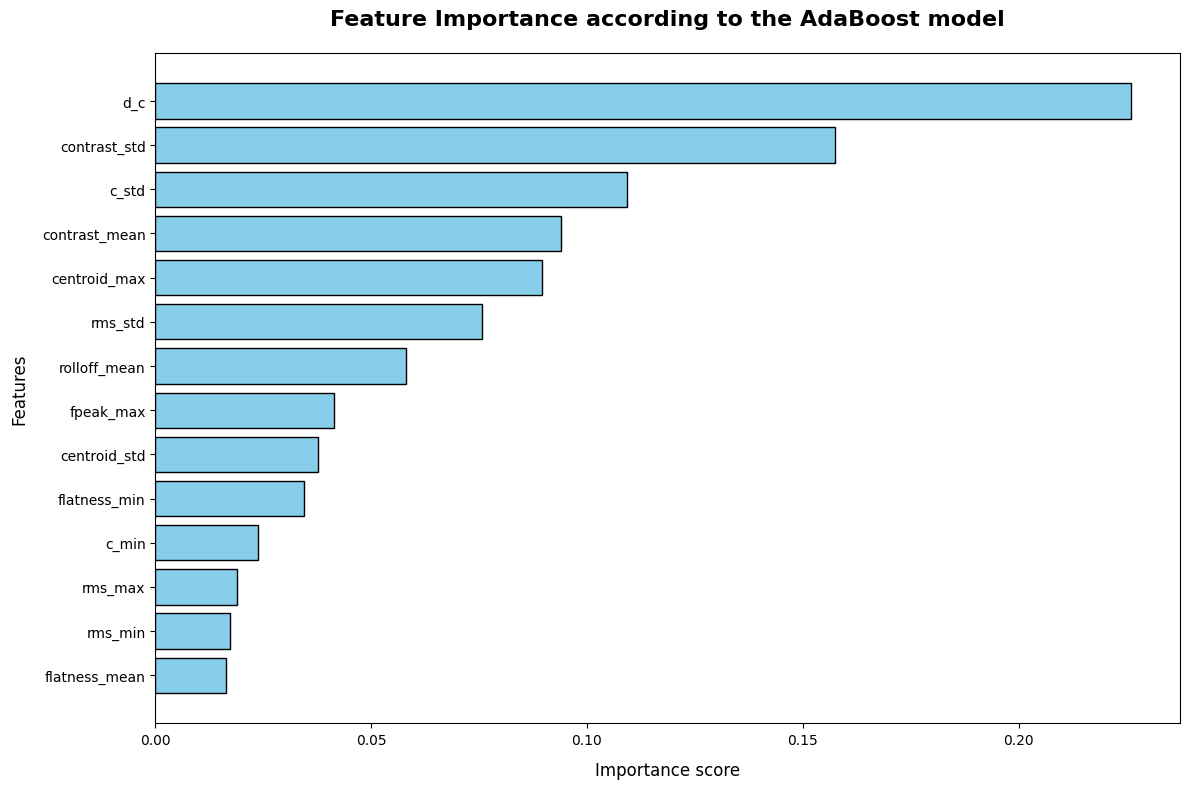

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Ensure the AdaBoost model is trained on the ENTIRE dataset X
# (Replace 'adaboost' with your actual AdaBoost model variable name)
#gb.fit(X, y)
adaboost.fit(X, y)

# 2. Extract feature importances
imp_adaboost = adaboost.feature_importances_
#imp_gb = gb.feature_importances_

feat = X.columns

# 3. Create DataFrame (keeping all features with importance > 0)
df_importance = pd.DataFrame({
    'importance': imp_adaboost,
    'feature': feat
})

# Filtering (Optional: you can increase to > 0.03 if you have too many features)
df_importance = df_importance[df_importance['importance'] > 0]

# 4. Sort in descending order (crucial for readability)
df_importance = df_importance.sort_values(by='importance', ascending=False)

print("--- Feature Importance - AdaBoost ---")
print(df_importance)

# 5. Plotting (Tip: A HORIZONTAL bar chart is much easier to read)
plt.figure(figsize=(12, 8))  # Adjusted size for visual harmony

# Use barh (horizontal bars) so that feature names are readable from left to right
plt.barh(df_importance['feature'], df_importance['importance'], color='skyblue', edgecolor='black')

plt.gca().invert_yaxis()  # Keep the most important feature at the top

# Font size adjustments for scientific publication standards
plt.title("Feature Importance according to the AdaBoost model", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Importance score", fontsize=12, labelpad=10)
plt.ylabel("Features", fontsize=12, labelpad=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()  # Prevents feature names from being clipped at the edges
plt.show()

--- Permutation Importance - Gradient Boosting ---
    importance feature
34    0.309677     d_c


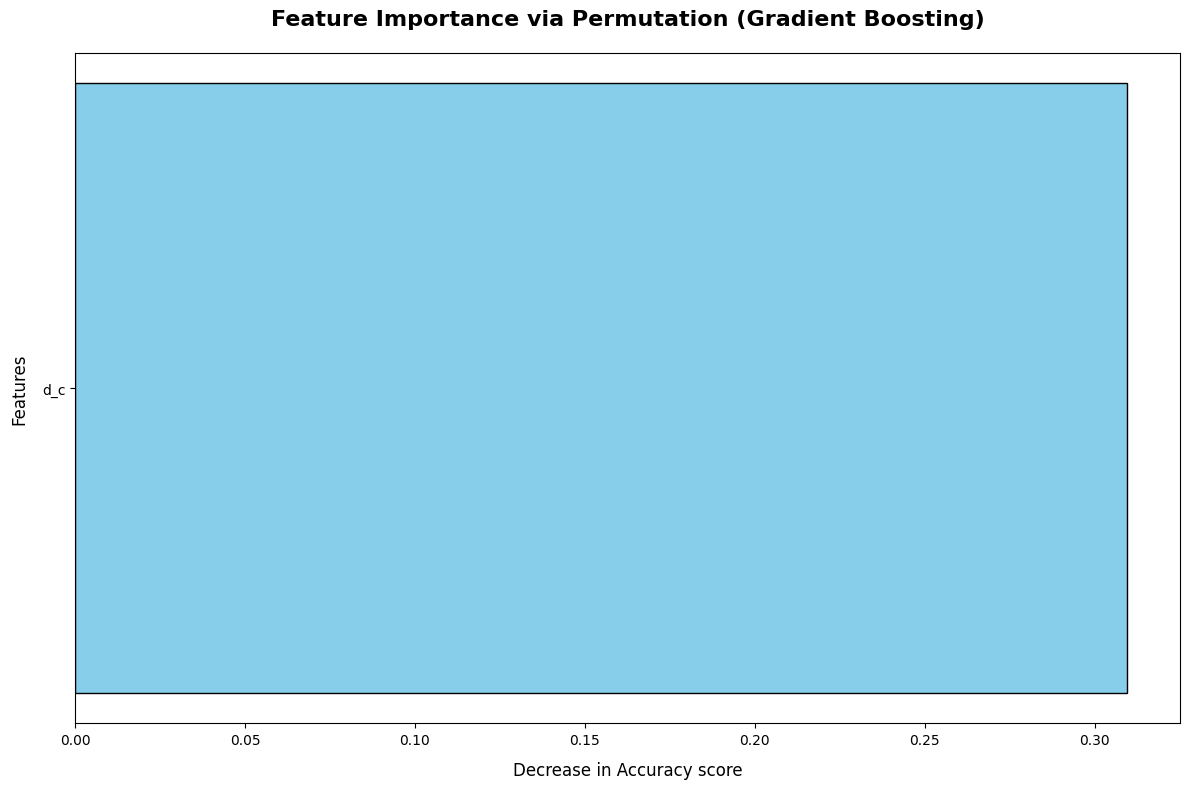

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# 1. Ensure the model is trained on the entire dataset
gb.fit(X, y)

# 2. Calculate permutation importance
result_gb = permutation_importance(gb, X, y, n_repeats=10, random_state=42)

# 3. Create the DataFrame
df_perm_gb = pd.DataFrame({
    'importance': result_gb.importances_mean,
    'feature': X.columns
})

# Filter to retain only features with a positive impact and sort in descending order
df_perm_gb = df_perm_gb[df_perm_gb['importance'] > 0].sort_values(by='importance', ascending=False)

print("--- Permutation Importance - Gradient Boosting ---")
print(df_perm_gb)

# 4. Display the horizontal bar chart
plt.figure(figsize=(12, 8))
plt.barh(df_perm_gb['feature'], df_perm_gb['importance'], color='skyblue', edgecolor='black')
plt.gca().invert_yaxis()  # Place the most important feature at the top
plt.title("Feature Importance via Permutation (Gradient Boosting)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Decrease in Accuracy score", fontsize=12, labelpad=10)
plt.ylabel("Features", fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()

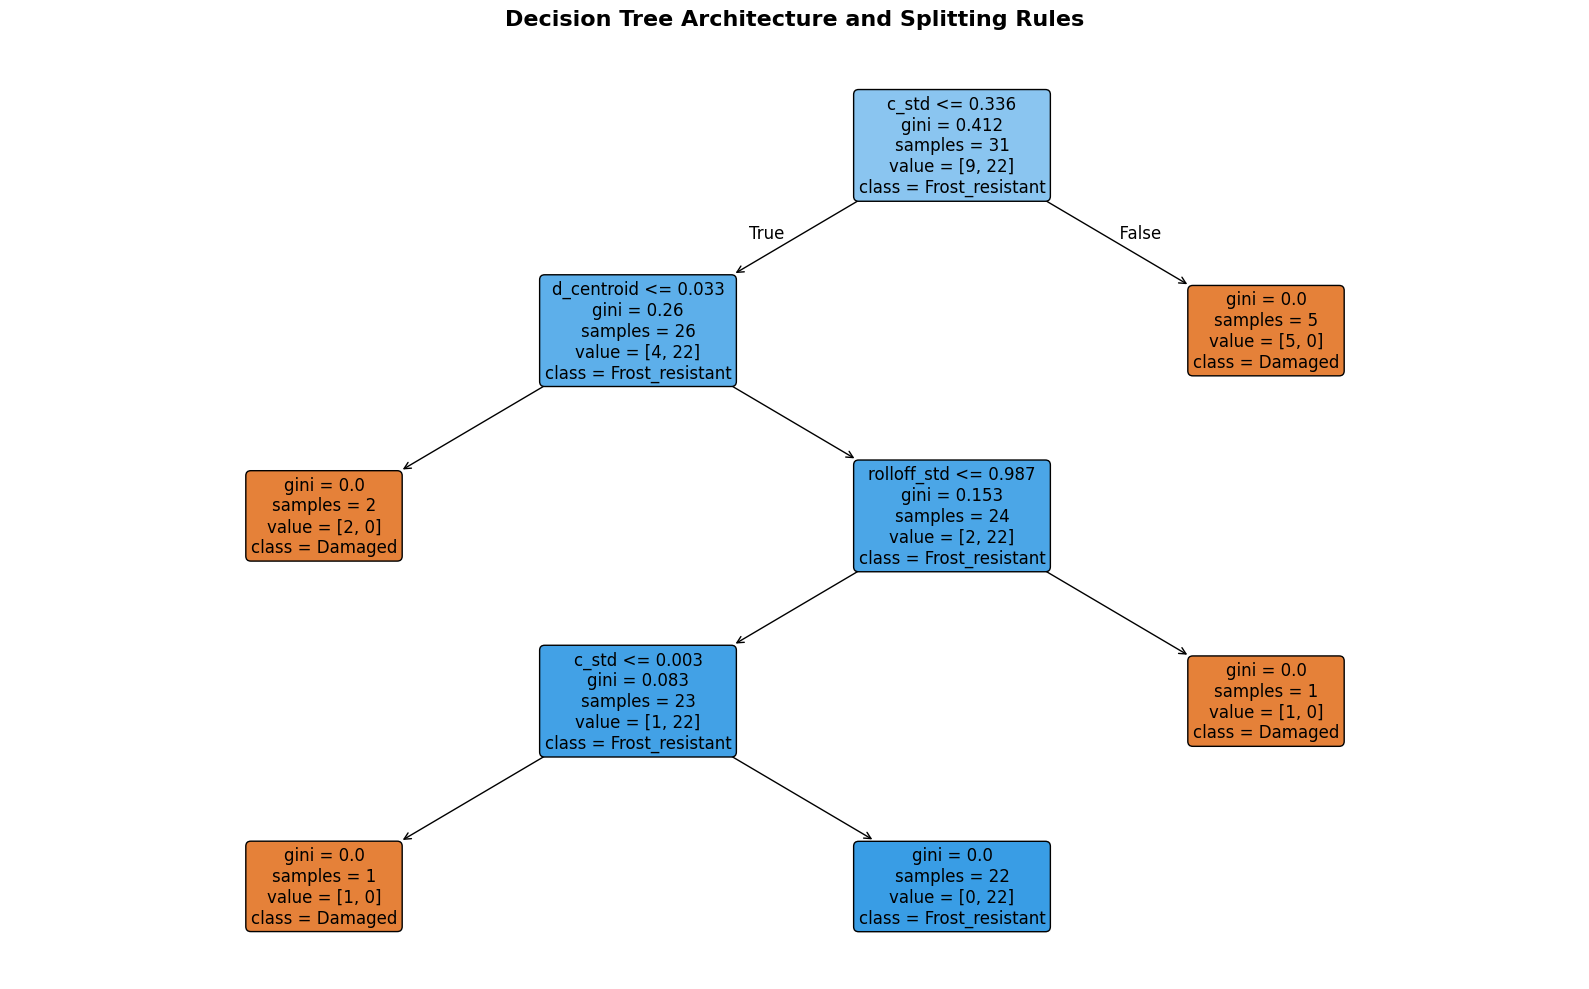

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# 1. Ensure the tree model is trained on the entire dataset
tree.fit(X, y)

# 2. Graphical display of the decision tree structure
plt.figure(figsize=(16, 10))
plot_tree(
    tree,
    feature_names=list(X.columns),
    class_names=['Damaged', 'Frost_resistant'],  # Adjust the order based on your class encoding if needed
    filled=True,          # Color nodes according to class purity
    rounded=True,         # Aesthetic rounded edges for the boxes
    fontsize=12           # Font size of the text inside the nodes
)

plt.title("Decision Tree Architecture and Splitting Rules", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 5. Correlations



In [ ]:
X_sub = df.drop(['sample_name',
'form',
 'rms_1',
 'rms_2',
 'rms_3',
 'rms_4',
 'rms_5',
 'rms_6',
 'rms_7',
 'rms_8',
 'rms_9',
 'flatness_1',
 'flatness_2',
 'flatness_3',
 'flatness_4',
 'flatness_5',
 'flatness_6',
 'flatness_7',
 'flatness_8',
 'flatness_9',
 'rolloff_1',
 'rolloff_2',
 'rolloff_3',
 'rolloff_4',
 'rolloff_5',
 'rolloff_6',
 'rolloff_7',
 'rolloff_8',
 'rolloff_9',
 'contrast_1',
 'contrast_2',
 'contrast_3',
 'contrast_4',
 'contrast_5',
 'contrast_6',
 'contrast_7',
 'contrast_8',
 'contrast_9',
 'fpeak_1',
 'fpeak_2',
 'fpeak_3',
 'fpeak_4',
 'fpeak_5',
 'fpeak_6',
 'fpeak_7',
 'fpeak_8',
 'fpeak_9',
 'c_1',
 'c_2',
 'c_3',
 'c_4',
 'c_5',
 'c_6',
 'c_7',
 'c_8',
 'c_9',
 'centroid_1',
 'centroid_2',
 'centroid_3',
 'centroid_4',
 'centroid_5',
 'centroid_6',
 'centroid_7',
 'centroid_8',
 'centroid_9'
                 ],axis=1)

In [ ]:
X_sub = X_sub.fillna(X_sub.mean())
X_sub = (X_sub-X_sub.min()) / (X_sub.max()-X_sub.min())

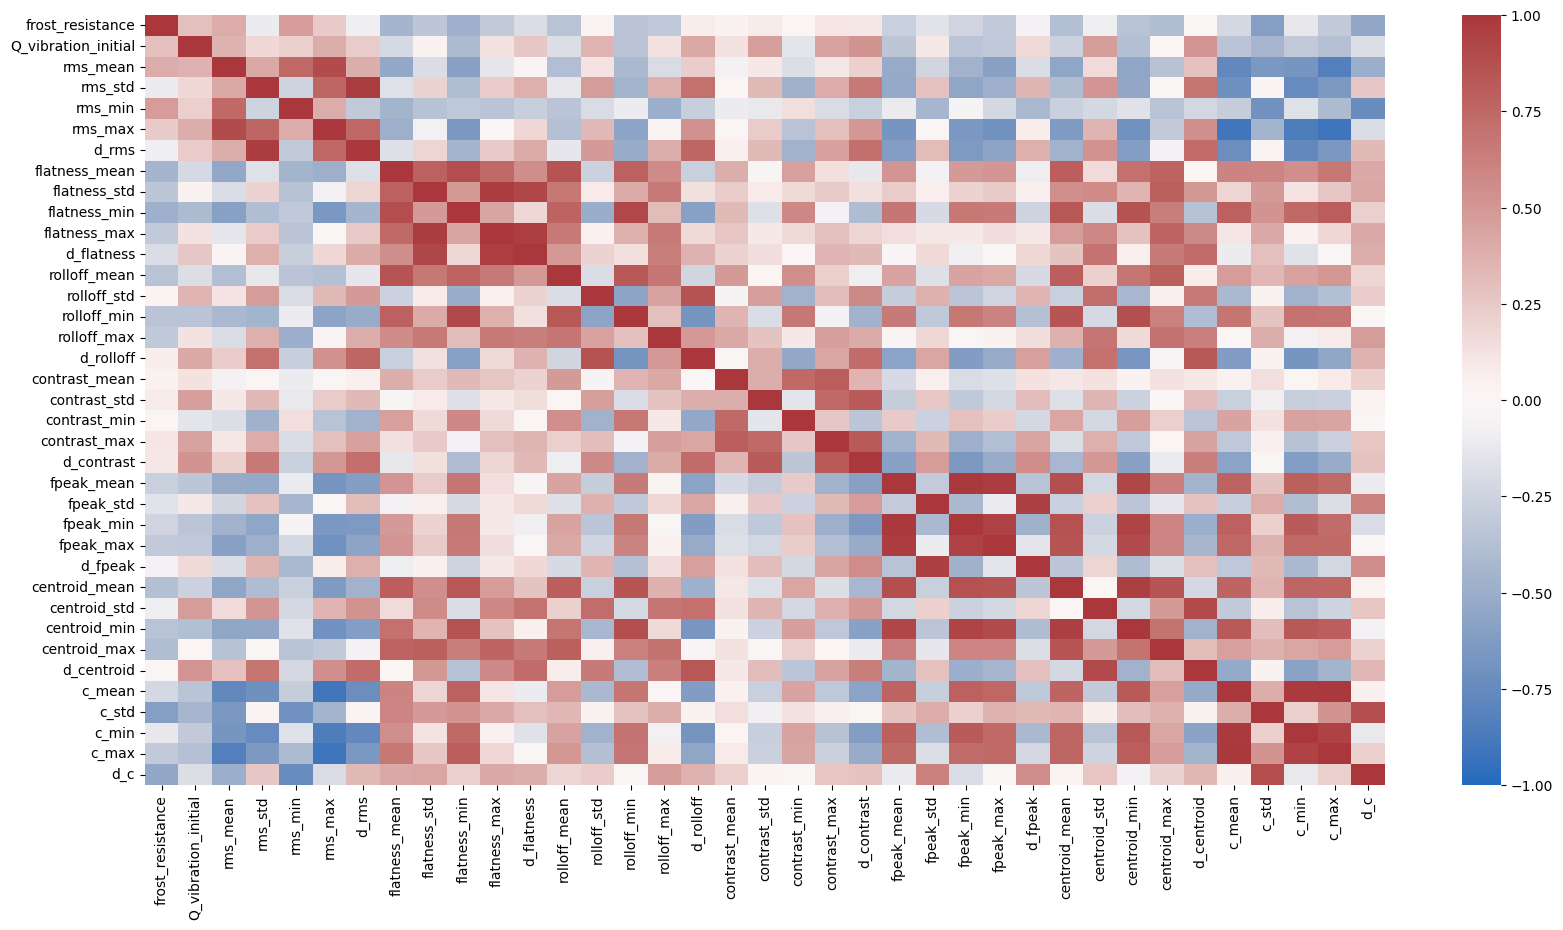

In [ ]:
plt.figure(figsize=(20, 10))
heatmap = sns.heatmap(X_sub.corr(), vmin=-1, vmax=1, cmap='vlag')
plt.show()

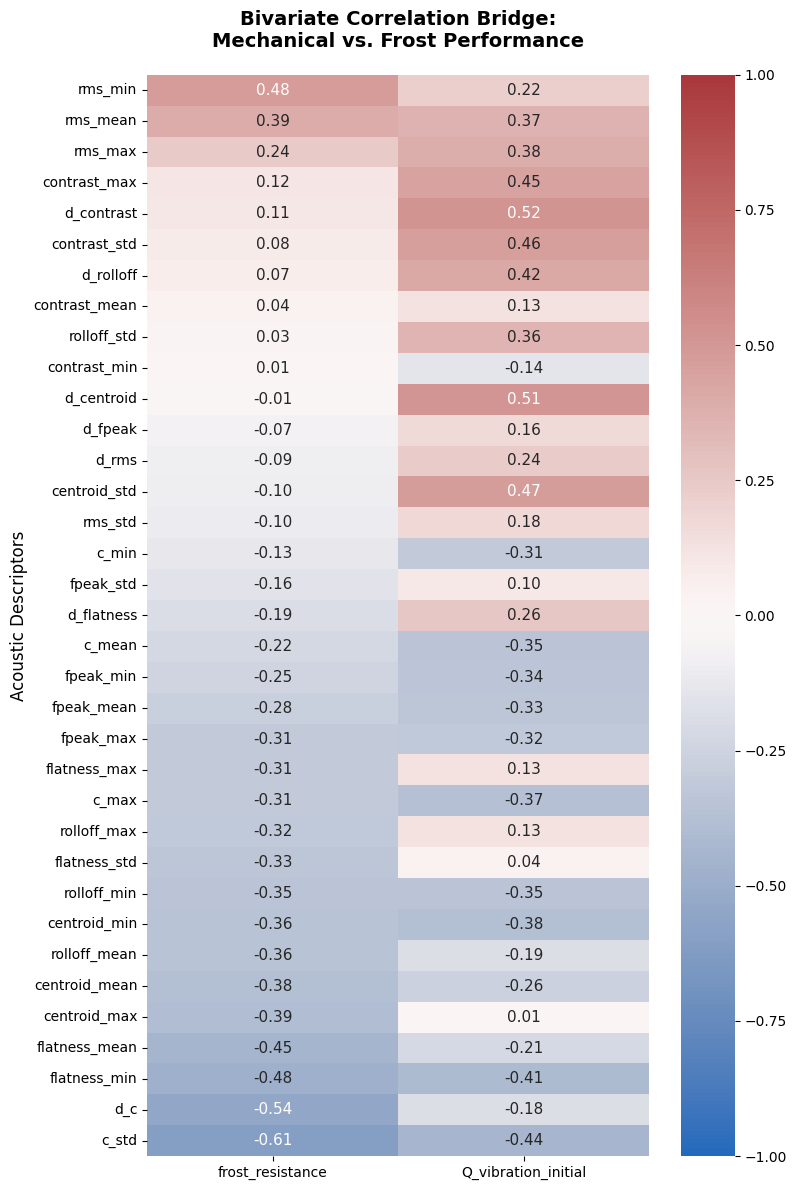

In [ ]:
# Select acoustic features (excluding the target variables)
acoustic_features = [col for col in X_sub.columns if col not in ['frost_resistance', 'Q_vibration_initial']]

# Compute specific cross-correlations
macro_micro_corr = X_sub.corr().loc[acoustic_features, ['frost_resistance', 'Q_vibration_initial']]

# Sort the values for a cleaner visual rendering
macro_micro_corr = macro_micro_corr.sort_values(by='frost_resistance', ascending=False)

plt.figure(figsize=(8, 12))
sns.heatmap(macro_micro_corr, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, cbar=True, annot_kws={"size": 11})

plt.title("Bivariate Correlation Bridge:\nMechanical vs. Frost Performance", fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Acoustic Descriptors", fontsize=12)
plt.tight_layout()
plt.show()

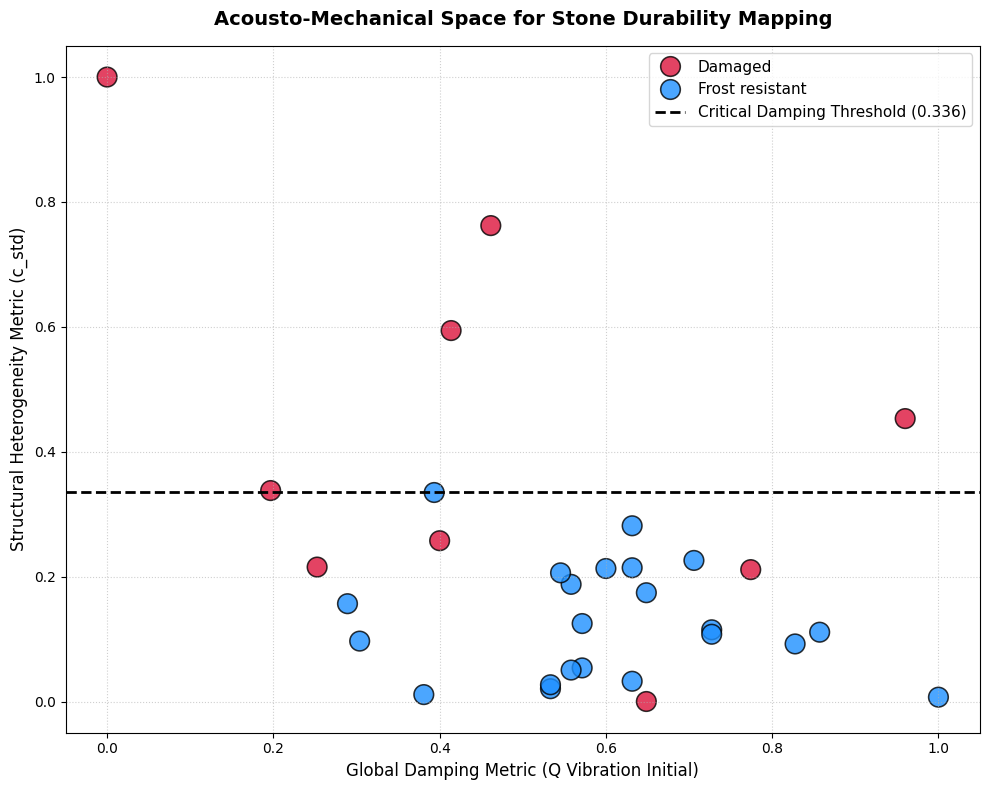

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# 1. Plot the scatterplot (0.0: crimson, 1.0: dodgerblue)
ax = sns.scatterplot(
    data=X_sub,
    x='Q_vibration_initial',
    y='c_std',
    hue='frost_resistance',
    palette={0.0: 'crimson', 1.0: 'dodgerblue'},
    hue_order=[0.0, 1.0], # 0.0 first (crimson), 1.0 second (dodgerblue)
    s=200,
    edgecolor='black',
    alpha=0.8
)

# 2. Add the threshold line from the decision tree
thresh_line = plt.axhline(y=0.336, color='black', linestyle='--', linewidth=2)

# 3. Retrieve the handles generated by Seaborn (contains exactly 2 elements: Crimson and Blue)
handles, labels = ax.get_legend_handles_labels()

# Append the threshold line to the list of handles
clean_handles = handles + [thresh_line]

# Map the exact custom labels to match the handle order:
# handles[0] (0.0 = Crimson) -> 'Damaged'
# handles[1] (1.0 = Blue)    -> 'Frost resistant'
# thresh_line (Line)         -> 'Critical Damping Threshold (0.336)'
custom_labels = ['Damaged', 'Frost resistant', 'Critical Damping Threshold (0.336)']

# Render the clean legend
plt.legend(clean_handles, custom_labels, fontsize=11, loc='upper right')

# 4. Titles, labels, and grid configuration
plt.title("Acousto-Mechanical Space for Stone Durability Mapping", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Global Damping Metric (Q Vibration Initial)", fontsize=12)
plt.ylabel("Structural Heterogeneity Metric (c_std)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

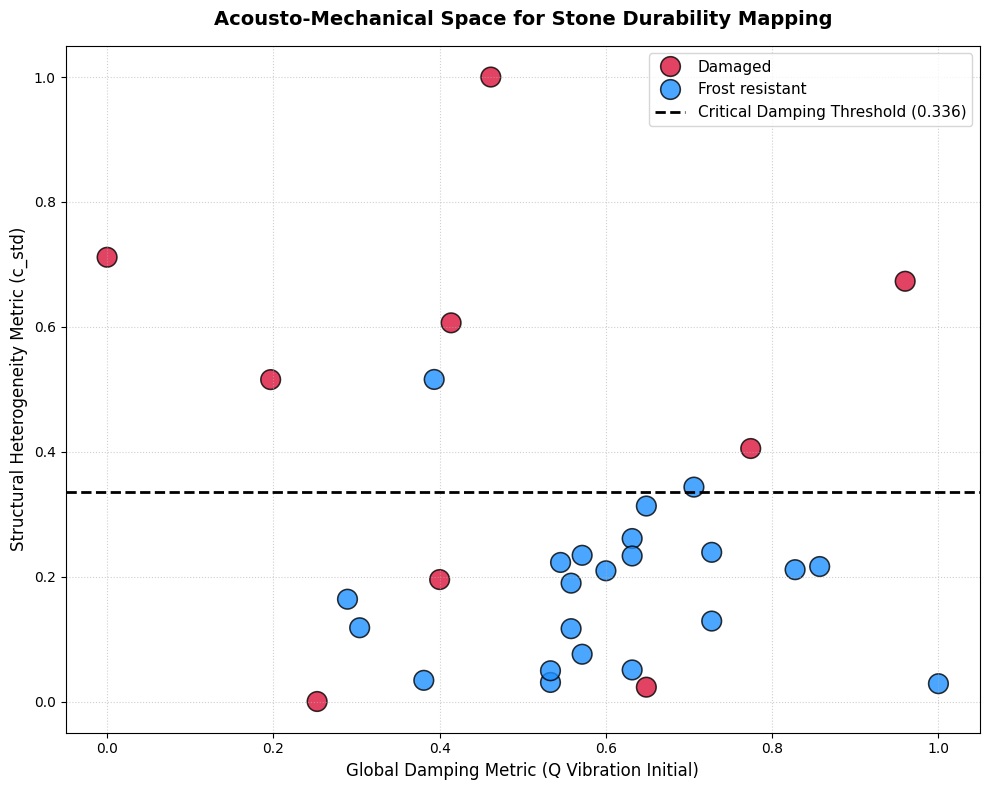

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# 1. Plot the scatterplot (0.0: crimson, 1.0: dodgerblue)
ax = sns.scatterplot(
    data=X_sub,
    x='Q_vibration_initial',
    #y='c_std',
    y='d_c',
    hue='frost_resistance',
    palette={0.0: 'crimson', 1.0: 'dodgerblue'},
    hue_order=[0.0, 1.0], # 0.0 first (crimson), 1.0 second (dodgerblue)
    s=200,
    edgecolor='black',
    alpha=0.8
)

# 2. Add the threshold line from the decision tree
thresh_line = plt.axhline(y=0.336, color='black', linestyle='--', linewidth=2)

# 3. Retrieve the handles generated by Seaborn (contains exactly 2 elements: Crimson and Blue)
handles, labels = ax.get_legend_handles_labels()

# Append the threshold line to the list of handles
clean_handles = handles + [thresh_line]

# Map the exact custom labels to match the handle order:
# handles[0] (0.0 = Crimson) -> 'Damaged'
# handles[1] (1.0 = Blue)    -> 'Frost resistant'
# thresh_line (Line)         -> 'Critical Damping Threshold (0.336)'
custom_labels = ['Damaged', 'Frost resistant', 'Critical Damping Threshold (0.336)']

# Render the clean legend
plt.legend(clean_handles, custom_labels, fontsize=11, loc='upper right')

# 4. Titles, labels, and grid configuration
plt.title("Acousto-Mechanical Space for Stone Durability Mapping", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Global Damping Metric (Q Vibration Initial)", fontsize=12)
plt.ylabel("Structural Heterogeneity Metric (c_std)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()